In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import joblib
import os



In [37]:
df = pd.read_csv("../data/raw/career_data.csv")
df.head()



,gender,ug_course,ug_specialization,interests,skills,cgpa,has_certification,certification_title,is_working,masters_field,job_title
0,Male,BCA,Visual Arts,"Creativity, Photography, Graphic Design, User ...","Figma, Adobe XD, Prototyping, Sketch, SQL",7.83,No,NaN,Yes,MS in Human-Computer Interaction,UI/UX Designer
1,Female,B.Tech,Computer Science,"App Development, Programming, Design","Linux, Java, Swift",8.25,Yes,Flutter Development Bootcamp,Yes,No Masters,Mobile App Developer
2,Male,MSc,Computer Science,"Mathematics, Sports, Research","Mathematics, Deep Learning, Research Writing",8.83,Yes,Reinforcement Learning Specialization,No,PhD in CS,AI Research Scientist
3,Female,B.Tech,Computer Science,"Sports, Data Analysis, Statistics, Machine Lea...","Teamwork, Python, SQL",8.00,Yes,IBM Data Science,Yes,No Masters,Data Scientist
4,Male,BBA,Computer Science,"Business Analysis, Sports, IT Management, Cons...","Excel, Project Management, SQL, Problem Solvin...",6.84,No,NaN,Yes,No Masters,IT Consultant


In [38]:
df.shape,df.dtypes,df.isnull().sum()

((3750, 11),
 gender                     str
 ug_course                  str
 ug_specialization          str
 interests                  str
 skills                     str
 cgpa                   float64
 has_certification          str
 certification_title        str
 is_working                 str
 masters_field              str
 job_title                  str
 dtype: object,
 gender                    0
 ug_course                 0
 ug_specialization         0
 interests                 0
 skills                    0
 cgpa                      0
 has_certification         0
 certification_title    1295
 is_working                0
 masters_field             0
 job_title                 0
 dtype: int64)

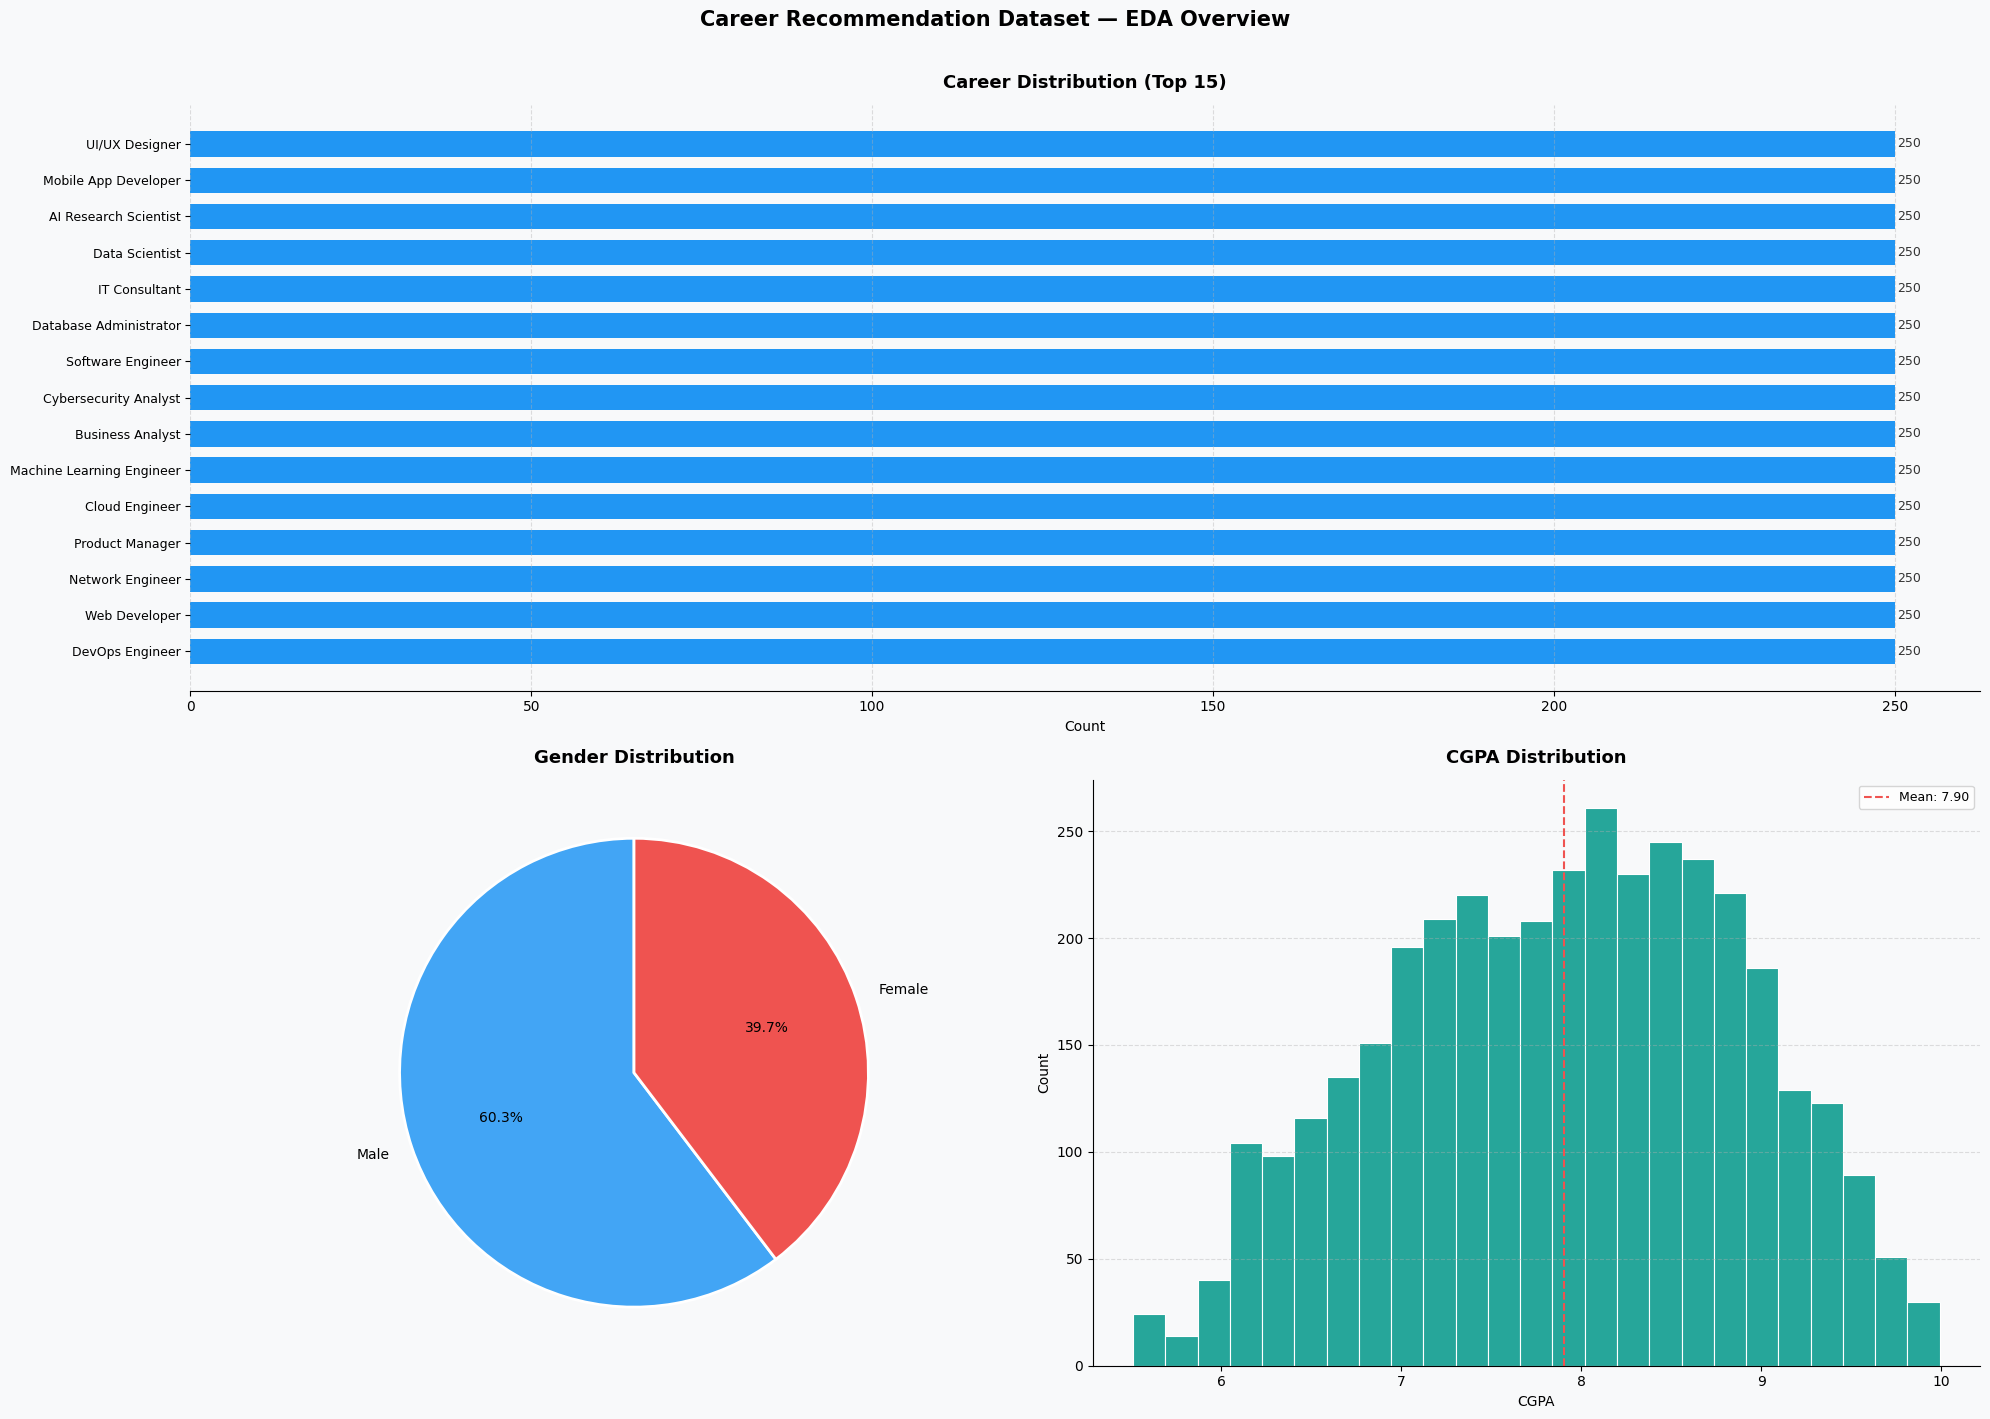

In [39]:
fig = plt.figure(figsize=(20, 14))
fig.patch.set_facecolor("#f8f9fa")

top_n = 15
career_counts = df["job_title"].value_counts().head(top_n)

ax1 = fig.add_subplot(2, 2, (1, 2))
bars = ax1.barh(career_counts.index[::-1], career_counts.values[::-1], color="#2196F3", edgecolor="none", height=0.7)
for bar, val in zip(bars, career_counts.values[::-1]):
    ax1.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2, str(val), va="center", fontsize=9, color="#333")
ax1.set_title(f"Career Distribution (Top {top_n})", fontsize=13, fontweight="bold", pad=12)
ax1.set_xlabel("Count", fontsize=10)
ax1.set_facecolor("#f8f9fa")
ax1.spines[["top","right","left"]].set_visible(False)
ax1.tick_params(axis="y", labelsize=9)
ax1.grid(axis="x", linestyle="--", alpha=0.4)

ax2 = fig.add_subplot(2, 2, 3)
gender_counts = df["gender"].value_counts()
colors = ["#42A5F5","#EF5350","#66BB6A"]
wedges, texts, autotexts = ax2.pie(
    gender_counts.values, labels=gender_counts.index,
    autopct="%1.1f%%", colors=colors[:len(gender_counts)],
    startangle=90, wedgeprops={"edgecolor": "white", "linewidth": 2}
)
for t in autotexts:
    t.set_fontsize(10)
ax2.set_title("Gender Distribution", fontsize=13, fontweight="bold", pad=12)

ax3 = fig.add_subplot(2, 2, 4)
ax3.hist(df["cgpa"], bins=25, color="#26A69A", edgecolor="white", linewidth=0.8)
ax3.set_title("CGPA Distribution", fontsize=13, fontweight="bold", pad=12)
ax3.set_xlabel("CGPA", fontsize=10)
ax3.set_ylabel("Count", fontsize=10)
ax3.set_facecolor("#f8f9fa")
ax3.spines[["top","right"]].set_visible(False)
ax3.axvline(df["cgpa"].mean(), color="#EF5350", linestyle="--", linewidth=1.5, label=f"Mean: {df['cgpa'].mean():.2f}")
ax3.legend(fontsize=9)
ax3.grid(axis="y", linestyle="--", alpha=0.4)

plt.suptitle("Career Recommendation Dataset — EDA Overview", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("../data/eda_overview.png", dpi=150, bbox_inches="tight")
plt.show()

In [40]:
target_col = "job_title"

le = LabelEncoder()
df[target_col] = le.fit_transform(df[target_col])

categorical_cols = df.select_dtypes(include="object").columns.tolist()

column_encoders = {}
for col in categorical_cols:
    col_enc = LabelEncoder()
    df[col] = col_enc.fit_transform(df[col].astype(str))
    column_encoders[col] = col_enc

X = df.drop(columns=[target_col])
y = df[target_col]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train shape : {X_train.shape}")
print(f"Test shape  : {X_test.shape}")
print(f"Classes     : {len(le.classes_)}")
print(f"Features    : {list(X.columns)}")

Train shape : (3000, 10)
Test shape  : (750, 10)
Classes     : 15
Features    : ['gender', 'ug_course', 'ug_specialization', 'interests', 'skills', 'cgpa', 'has_certification', 'certification_title', 'is_working', 'masters_field']


In [41]:
model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

test_acc    = accuracy_score(y_test, y_pred)
macro_f1    = f1_score(y_test, y_pred, average="macro", zero_division=0)
weighted_f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)

print(f"Test Accuracy : {test_acc:.4f}")
print(f"Macro F1      : {macro_f1:.4f}")
print(f"Weighted F1   : {weighted_f1:.4f}")

Test Accuracy : 0.9133
Macro F1      : 0.9133
Weighted F1   : 0.9133


                           precision    recall  f1-score   support

    AI Research Scientist       0.88      0.88      0.88        50
         Business Analyst       0.91      0.86      0.89        50
           Cloud Engineer       0.88      0.90      0.89        50
    Cybersecurity Analyst       0.89      0.94      0.91        50
           Data Scientist       0.98      0.94      0.96        50
   Database Administrator       0.90      0.92      0.91        50
          DevOps Engineer       0.90      0.94      0.92        50
            IT Consultant       0.94      0.90      0.92        50
Machine Learning Engineer       0.86      0.86      0.86        50
     Mobile App Developer       0.94      0.96      0.95        50
         Network Engineer       0.92      0.94      0.93        50
          Product Manager       0.88      0.92      0.90        50
        Software Engineer       0.89      0.96      0.92        50
           UI/UX Designer       0.96      0.92      0.94     

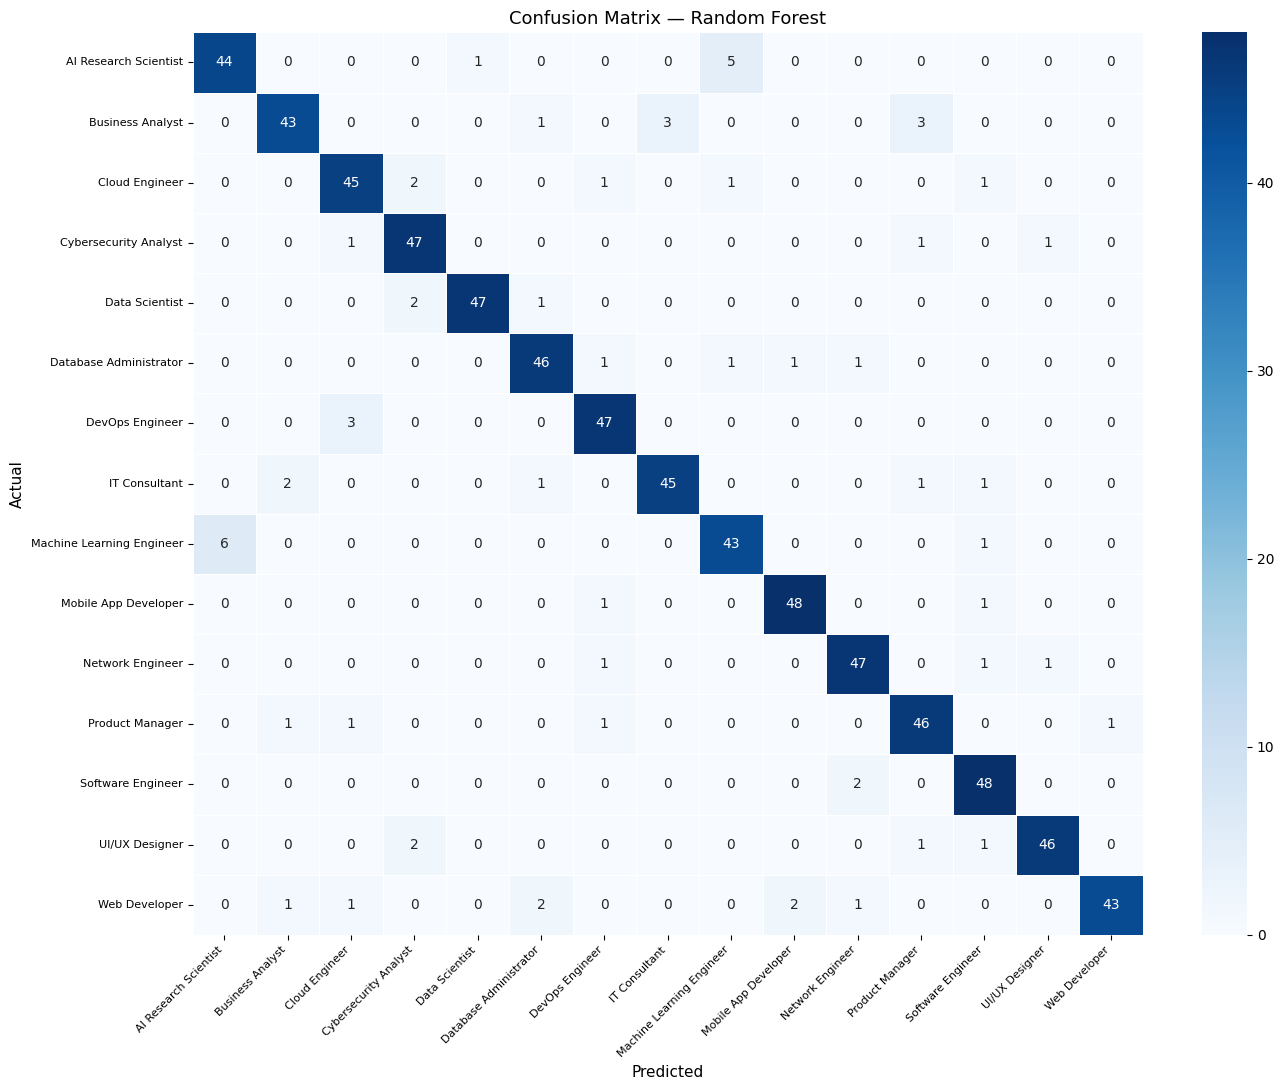

In [42]:
print(classification_report(y_test, y_pred, target_names=le.classes_, zero_division=0))

fig, ax = plt.subplots(figsize=(14, 11))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=le.classes_, yticklabels=le.classes_,
    ax=ax, linewidths=0.5
)
ax.set_xlabel("Predicted", fontsize=11)
ax.set_ylabel("Actual", fontsize=11)
ax.set_title(f"Confusion Matrix — Random Forest", fontsize=13)
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig("../data/confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

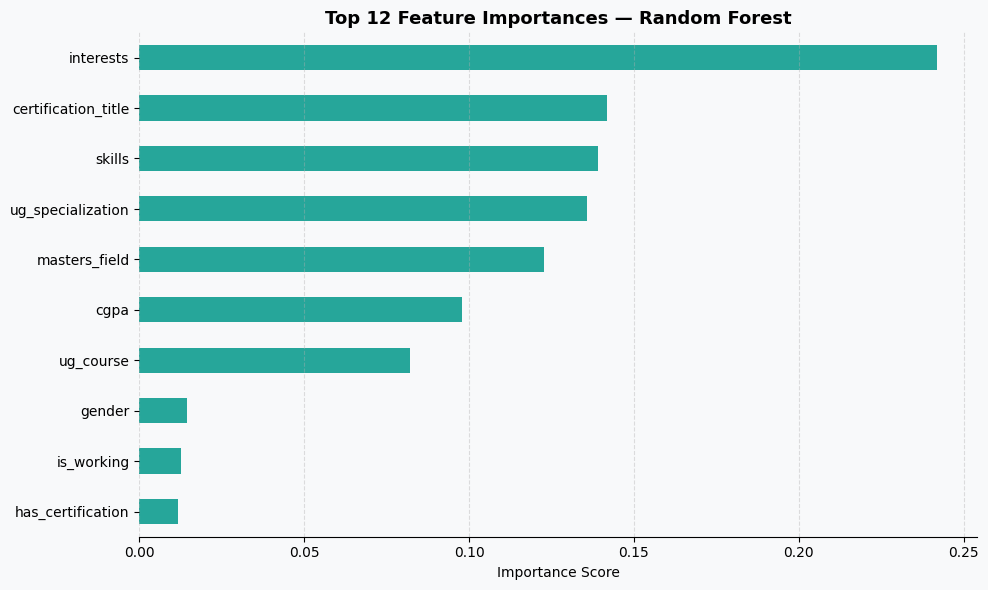

In [43]:
importances = pd.Series(model.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False).head(12)

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor("#f8f9fa")
importances.plot(kind="barh", ax=ax, color="#26A69A", edgecolor="none")
ax.set_title("Top 12 Feature Importances — Random Forest", fontsize=13, fontweight="bold")
ax.set_xlabel("Importance Score")
ax.invert_yaxis()
ax.spines[["top","right","left"]].set_visible(False)
ax.grid(axis="x", linestyle="--", alpha=0.4)
ax.set_facecolor("#f8f9fa")
plt.tight_layout()
plt.savefig("../data/feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

In [44]:
joblib.dump(model,            "../model/artifacts/model.pkl")
joblib.dump(scaler,           "../model/artifacts/scaler.pkl")
joblib.dump(le,               "../model/artifacts/label_encoder.pkl")
joblib.dump(list(X.columns),  "../model/artifacts/feature_names.pkl")
joblib.dump(column_encoders,  "../model/artifacts/column_encoders.pkl")

print(f"Model        : Random Forest")
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Classes      : {list(le.classes_)}")
print(f"Features     : {list(X.columns)}")
print(f"Col encoders : {list(column_encoders.keys())}")
print("\nAll artifacts saved to model/artifacts/")

Model        : Random Forest
Test Accuracy: 0.9133
Classes      : ['AI Research Scientist', 'Business Analyst', 'Cloud Engineer', 'Cybersecurity Analyst', 'Data Scientist', 'Database Administrator', 'DevOps Engineer', 'IT Consultant', 'Machine Learning Engineer', 'Mobile App Developer', 'Network Engineer', 'Product Manager', 'Software Engineer', 'UI/UX Designer', 'Web Developer']
Features     : ['gender', 'ug_course', 'ug_specialization', 'interests', 'skills', 'cgpa', 'has_certification', 'certification_title', 'is_working', 'masters_field']
Col encoders : ['gender', 'ug_course', 'ug_specialization', 'interests', 'skills', 'has_certification', 'certification_title', 'is_working', 'masters_field']

All artifacts saved to model/artifacts/
